Customer Churn Prediction

step 1 imports

In [1]:
#standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

#Sklearn imports
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

#Metrics & utilities
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')   

#Display settings
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
pd.set_option('display.max_columns', 200)

Step 2. Load the data

In [2]:
#Load dataset (adjust path if needed)
df = pd.read_csv('./customer_data.csv')  # Replace 'data.csv' with your dataset path
print("Shape", df.shape)
df.head()

Shape (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Step 3. initial inspection

In [3]:
# Info & summary
display(df.info())
display(df.describe(include='all'). T)

#Missing values
print("Missing values:\n", df.isnull().sum())

#Target distribution
print("\nChurn value counts:")
print(df['churn'].value_counts(normalize=False))
print("\Churn proportion:")
print(df['churn'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
credit_score,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
country,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
products_number,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
credit_card,10000.0,NaN,NaN,NaN,0.7055,0.45584,0.0,0.0,1.0,1.0,1.0
active_member,10000.0,NaN,NaN,NaN,0.5151,0.499797,0.0,0.0,1.0,1.0,1.0


Missing values:
 customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Churn value counts:
churn
0    7963
1    2037
Name: count, dtype: int64
\Churn proportion:
churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64


Step 4. Exploratory Data Analysis (Visualizations)

we'll look at distributions of numeric features, relationships with churn and categorical features.

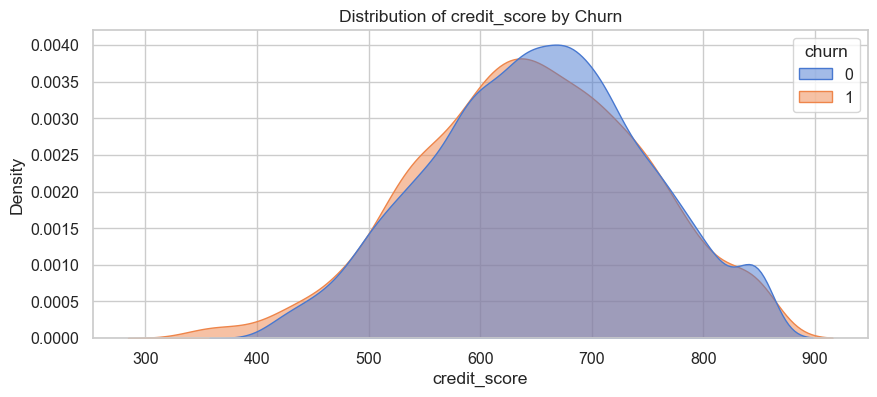

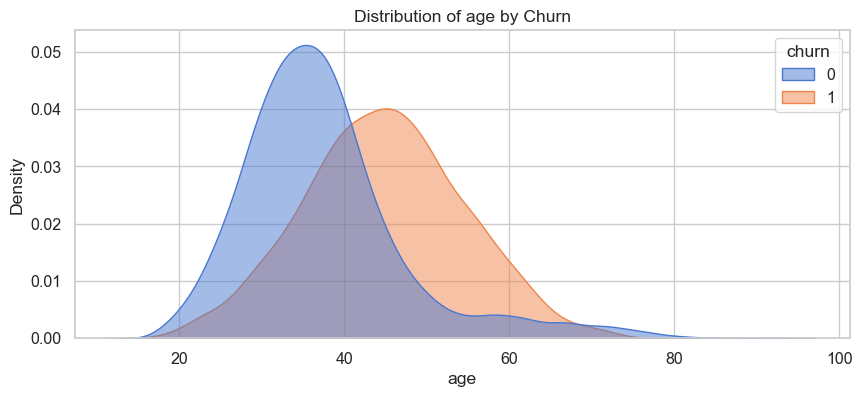

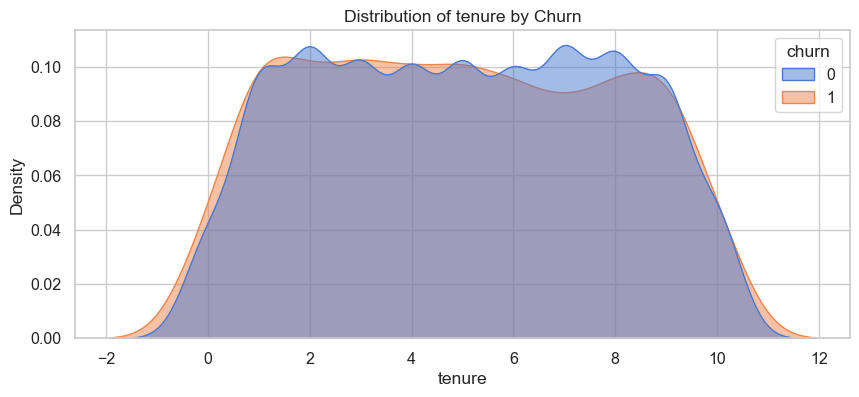

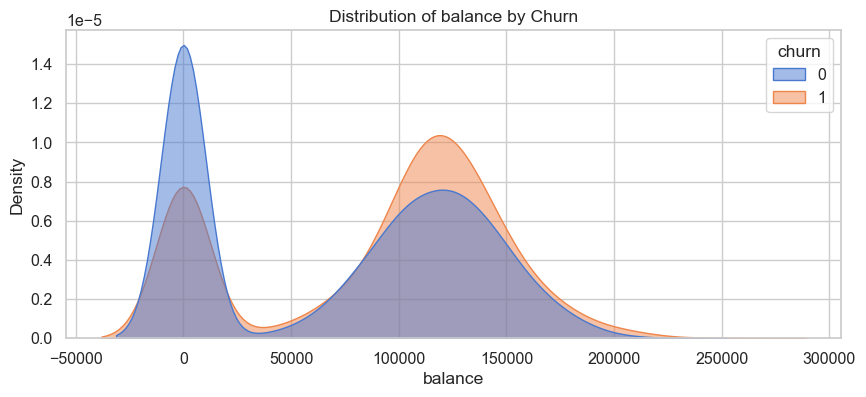

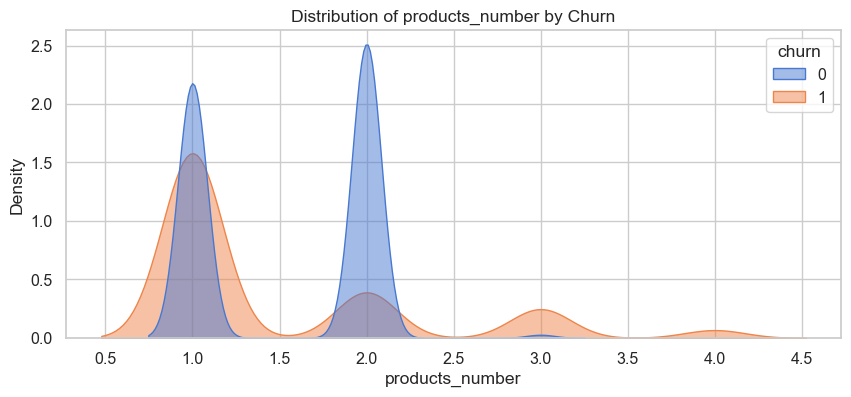

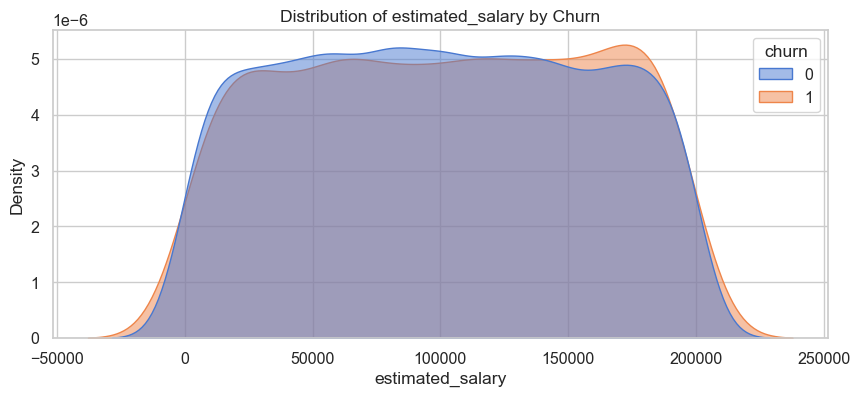

In [4]:
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

# .... Distribution plots for numerical features
for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(data=df, x=col, hue='churn', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'Distribution of {col} by Churn')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

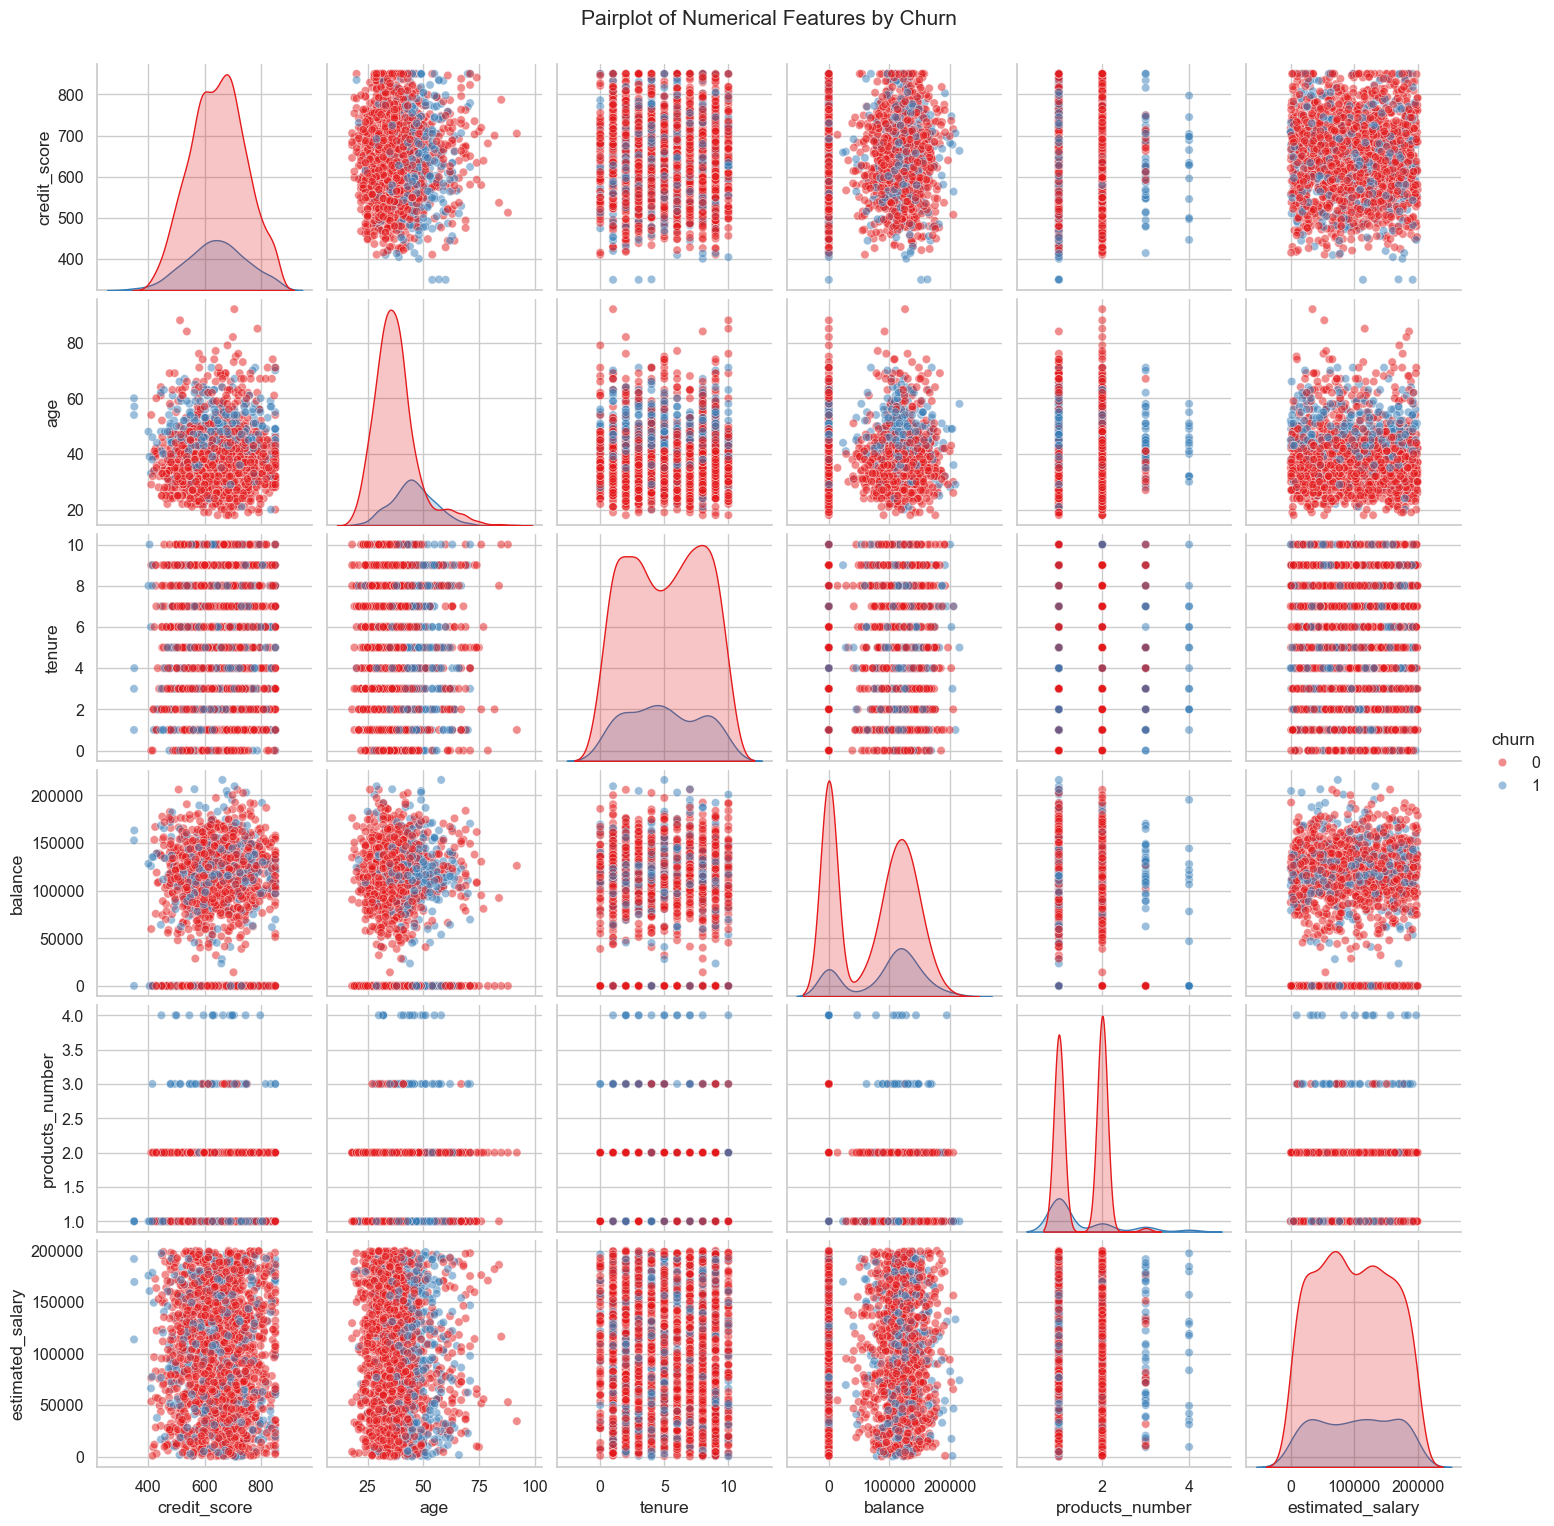

In [5]:
# pairplot (sampled for speed)
sns.pairplot(df.sample(frac=0.2, random_state = 42),
             vars=['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary'],
             hue='churn', palette='Set1', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Numerical Features by Churn', y=1.02)
plt.show()

Text(0.5, 1.0, 'Age Distribution by Churn')

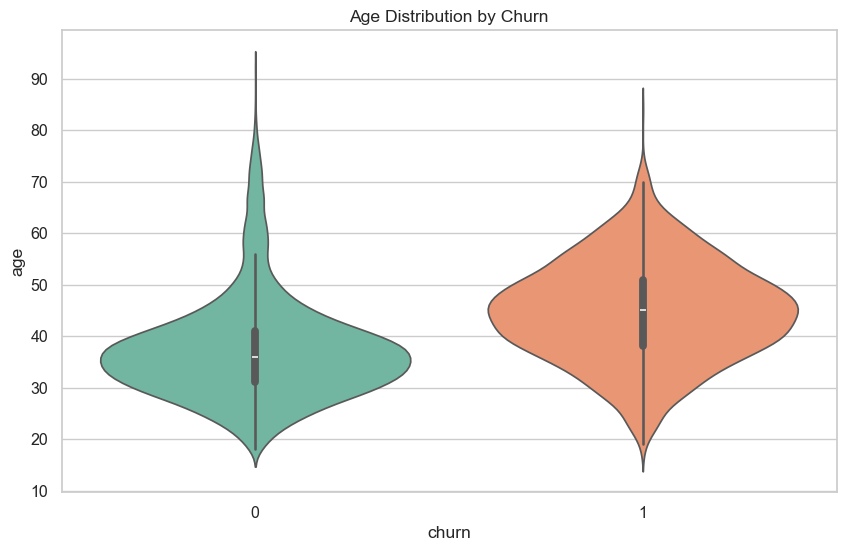

In [6]:
#violin plot for age
plt.figure(figsize=(10, 6))
sns.violinplot(x='churn', y='age', data=df, palette='Set2')
plt.title('Age Distribution by Churn')

Text(0.5, 1.0, 'Tenure Count by Churn')

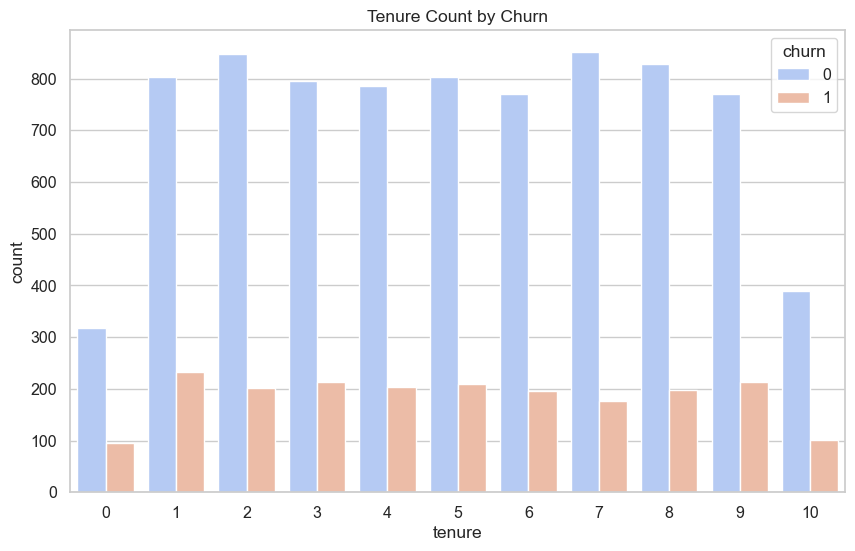

In [7]:
# ---  ---
plt.figure(figsize=(10, 6))
sns.countplot(x='tenure', hue='churn', data=df, palette='coolwarm')
plt.title('Tenure Count by Churn')

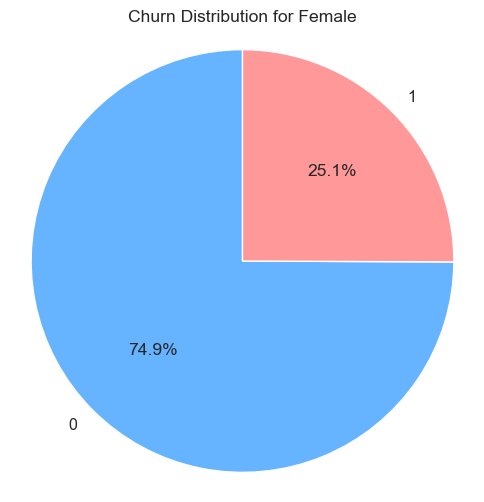

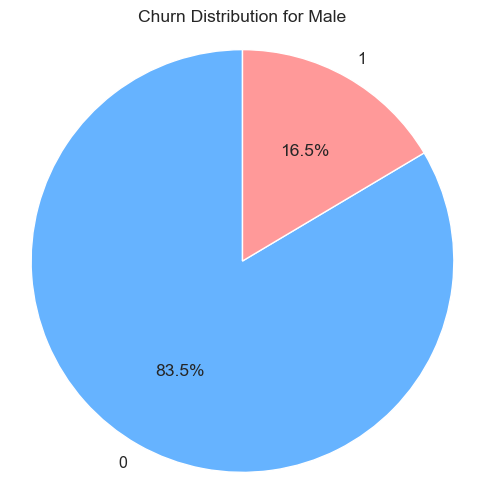

In [8]:
# --- gender vs churn donut chart
gender_counts = df.groupby('gender')['churn'].value_counts(normalize='True').unstack().fillna(0)
for gender in gender_counts.index:
    plt.figure(figsize=(6, 6))
    plt.pie(gender_counts.loc[gender], labels=gender_counts.columns, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
    plt.title(f'Churn Distribution for {gender}')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

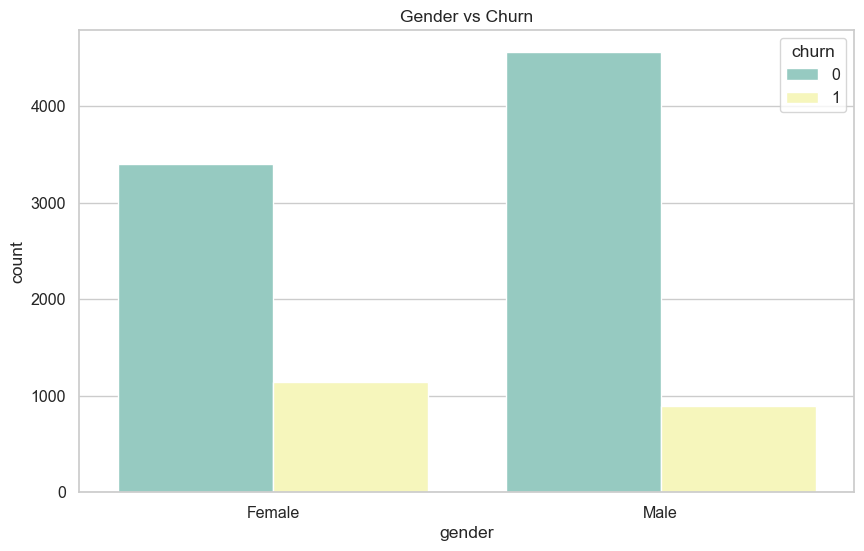

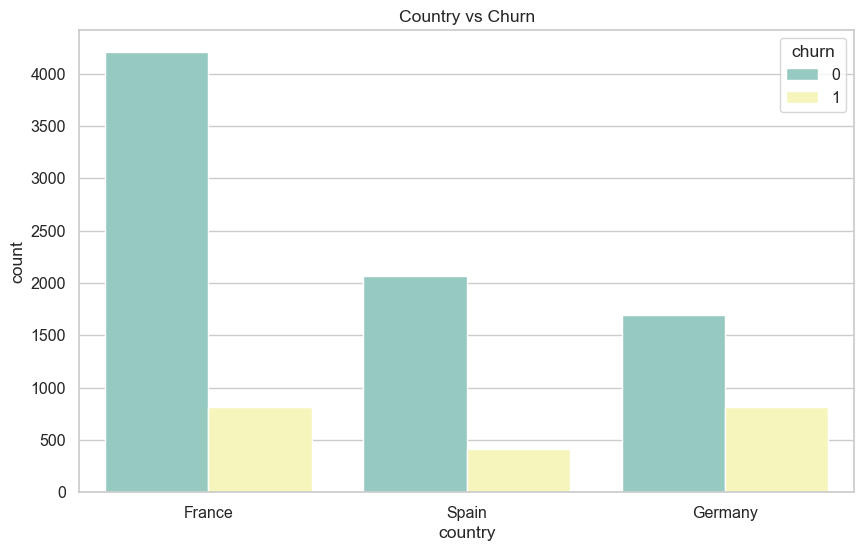

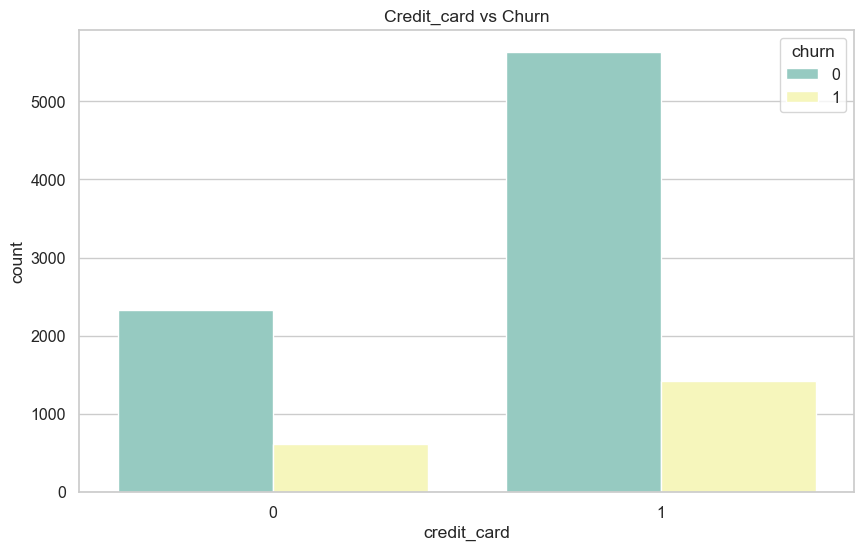

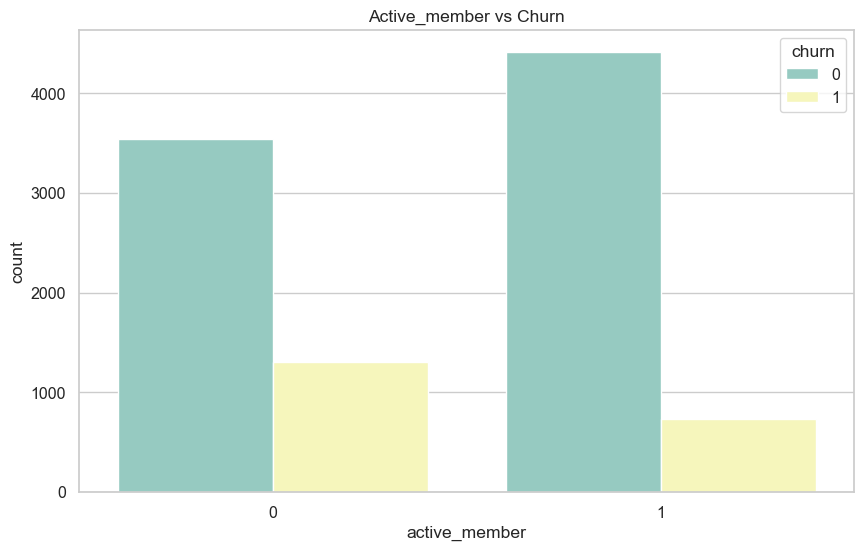

In [9]:
#---categorical features
cat_cols = ['gender', 'country', 'credit_card', 'active_member']
for c in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=c, hue='churn', data=df, palette='Set3')
    plt.title(f'{c.capitalize()} vs Churn')
    plt.show()

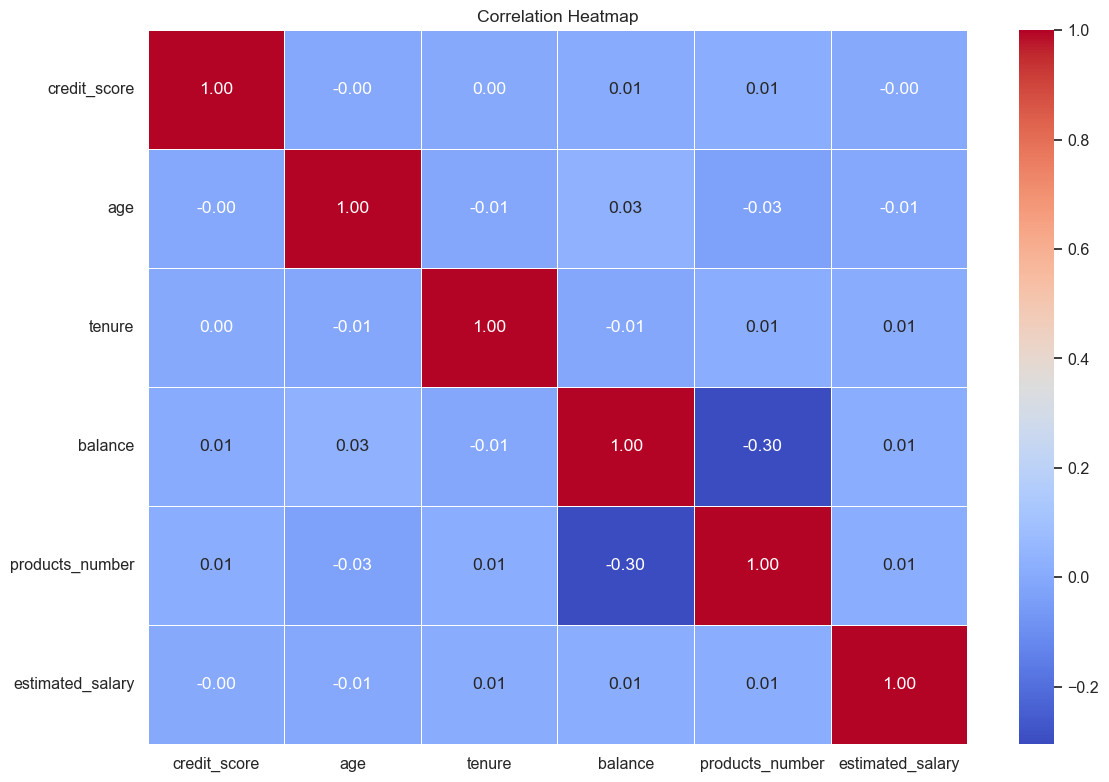

In [10]:
# --- heatmap visualization --- normalement c'est pour les features numeriques
numeric_df = df[num_cols]

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [11]:
# --- Numeric Correlation heatmap
corr=numeric_df.corr()
corr.style.background_gradient(cmap='coolwarm')

,credit_score,age,tenure,balance,products_number,estimated_salary
credit_score,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384
age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201
tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784
balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797
products_number,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204
estimated_salary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000


Text(0.5, 1.0, 'Balance vs Products Number by Churn')

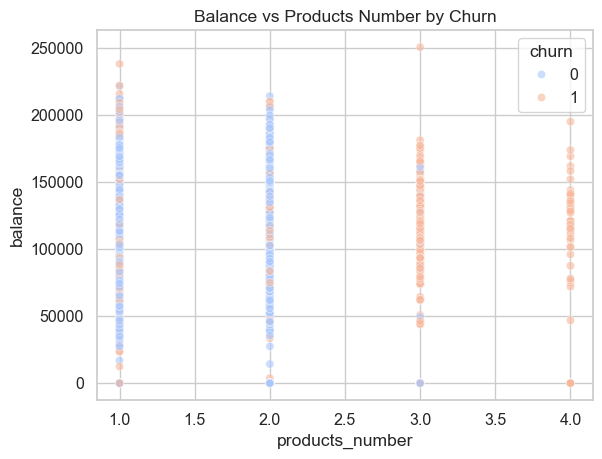

In [12]:
# --- balance vs products scatter
plt.Figure(figsize=(10, 6))
sns.scatterplot(data=df, y='balance', x='products_number', hue='churn', palette='coolwarm', alpha=0.6)
plt.title('Balance vs Products Number by Churn')

Text(0.5, 1.0, 'Churn Rate by Number of Products')

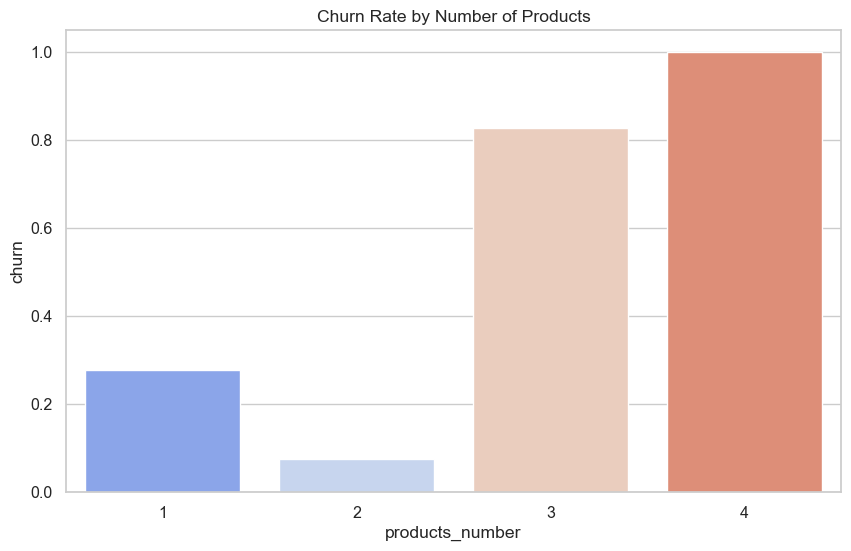

In [13]:
# --- aggregate churn rate per number of products
churn_rate = df.groupby('products_number')['churn'].mean().reset_index()

# Plot churn rate
plt.figure(figsize=(10, 6))
sns.barplot(data=churn_rate, x='products_number', y='churn', palette='coolwarm')
plt.title('Churn Rate by Number of Products')

# Step 5. Feature Engineering
Create meaningful features: e.g balance per product, age group, salary bracket and handel missing values.

In [15]:
# feature engineering examples
df_fe = df.copy()
#balance per product
df_fe['balance_per_product'] = df_fe['balance'] / (df_fe['products_number'].replace(0, np.nan))  # Avoid division by zero
df_fe['balance_per_product'].fillna(0, inplace=True)  # Fill NaN values with 0

#salary to balance ratio
df_fe['salary_balance_ratio'] = df_fe['estimated_salary'] / (df_fe['balance'].replace(0, np.nan))  # Avoid division by zero
df_fe['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace infinite values with 0
df_fe['salary_balance_ratio'].fillna(df_fe['salary_balance_ratio'].mean(), inplace=True)  # Fill NaN values with mean

# age group
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df_fe['age_group'] = pd.cut(df_fe['age'], bins=bins, labels=labels)

#Tenure bucket
df_fe['tenure_bucket'] = pd.cut(df_fe['tenure'], bins=[0, 1, 2, 5, 10, 100], labels=['0', '1-2', '3-5', '6-10', '10+'])

#Flag high balance
df_fe['high_balance'] = (df_fe['balance'] > df_fe['balance'].quantile(0.75)).astype(int)

# Quick checks
df_fe[['balance_per_product', 'salary_balance_ratio', 'age_group', 'tenure_bucket', 'high_balance']].head()

,balance_per_product,salary_balance_ratio,age_group,tenure_bucket,high_balance
0,0.000000,0.917399,35-44,1-2,0
1,83807.860000,1.342864,35-44,0,0
2,53220.266667,0.713585,35-44,6-10,1
3,0.000000,0.917399,35-44,0,0
4,125510.820000,0.630098,35-44,1-2,0


# Step 6. Preprocessing - encoding & scaling

we'll build a preprocessing pipeline that encodes categorical features and scales numerical ones

In [16]:
#Define features and target
target = 'churn'
drop_cols = ['customer_id'] # we ignore this column as it is an identifier and not useful for prediction
features = [c for c in df_fe.columns if c not in [target] + drop_cols]

numeric_features = [
    'credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary',
    'balance_per_product', 'salary_balance_ratio'
]

categorical_features = ['gender', 'country', 'credit_card', 'active_member', 'age_group', 'tenure_bucket', 'high_balance']

df_fe[categorical_features] = df_fe[categorical_features].astype('object')

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_per_product', 'salary_balance_ratio']
Categorical features: ['gender', 'country', 'credit_card', 'active_member', 'age_group', 'tenure_bucket', 'high_balance']


# Step 7. Train Test split

In [17]:
X = df_fe[features]
y = df_fe[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set shape:", X_train.shape, "Test set shape:", X_test.shape)
print("Training set churn distribution:\n", y_train.mean())
print("Test set churn distribution:\n", y_test.mean())

Training set shape: (8000, 15) Test set shape: (2000, 15)
Training set churn distribution:
 0.20375
Test set churn distribution:
 0.2035


# Step 8. Train multiple models with a pipeline and compare using cross-validation

In [18]:
# --- un dictionnaire des models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200,random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVC': SVC(probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    print(f"{name}: Mean ROC AUC: {scores.mean():.4f}, Std: {scores.std():.4f}")

Logistic Regression: Mean ROC AUC: 0.7876, Std: 0.0244
RandomForest: Mean ROC AUC: 0.8478, Std: 0.0148
GradientBoosting: Mean ROC AUC: 0.8628, Std: 0.0102
AdaBoost: Mean ROC AUC: 0.8462, Std: 0.0133
SVC: Mean ROC AUC: 0.8346, Std: 0.0104


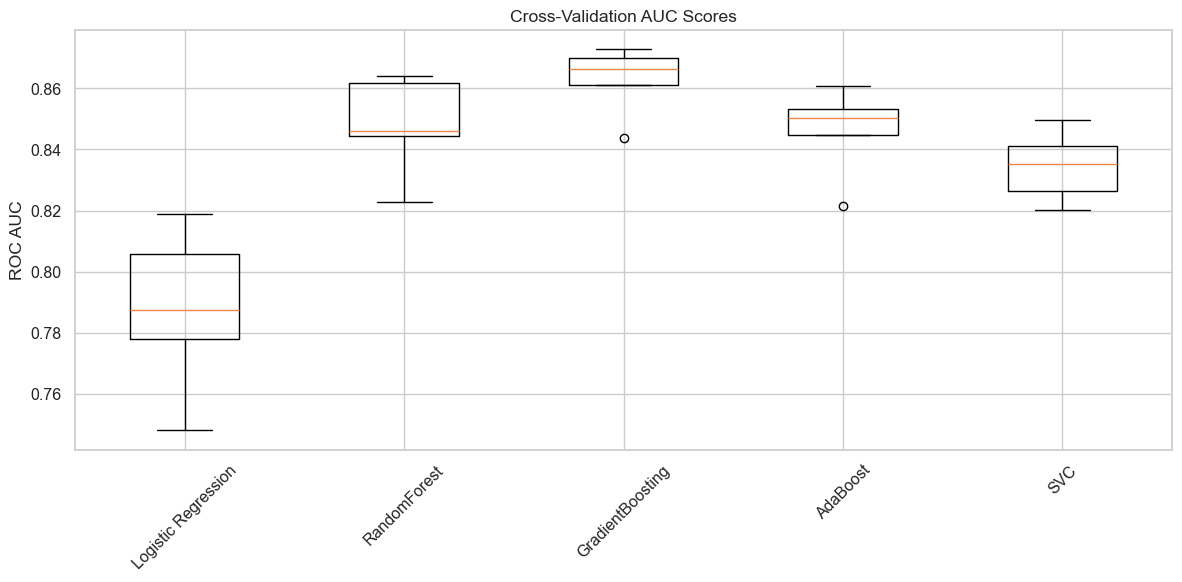

In [19]:
# Boxplot of CV (Cross Validation) AUC scores for each model
plt.figure(figsize=(12, 6))
plt.boxplot([results[name] for name in models.keys()], labels=models.keys())
plt.ylabel('ROC AUC')
plt.title('Cross-Validation AUC Scores')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 9. Fit best model on full train set and evaluate on test set
Select best model by mean CVAUC above and evaluate standard metrics on the test set

In [21]:
# Choose best model (automatic pick by mean AUC)
best_name = max(results.keys(), key=lambda k: results[k].mean())
best_name, results[best_name].mean()

('GradientBoosting', np.float64(0.862811202819967))

Best Model: GradientBoosting
Accuracy: 0.8665
Precision: 0.7756
Recall: 0.4840
F1-Score: 0.5961
ROC-AUC: 0.8716

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000



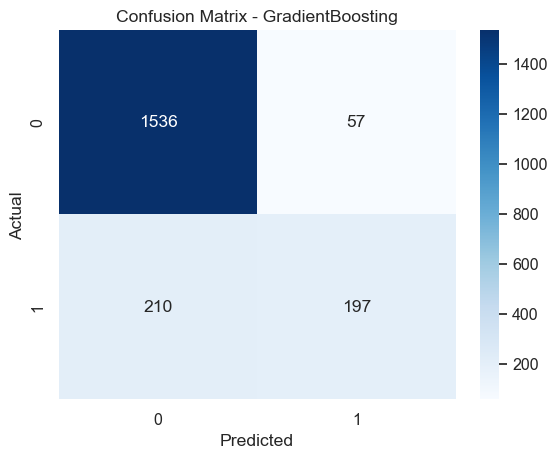

In [22]:
best_model = models[best_name]
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])
best_pipeline.fit(X_train, y_train)

# Predictions
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Best Model: {best_name}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

# Step 10. Feature importance (if applicable)
if the chosen model supports feature importance (RandomForest/GradientBoosting), show top features

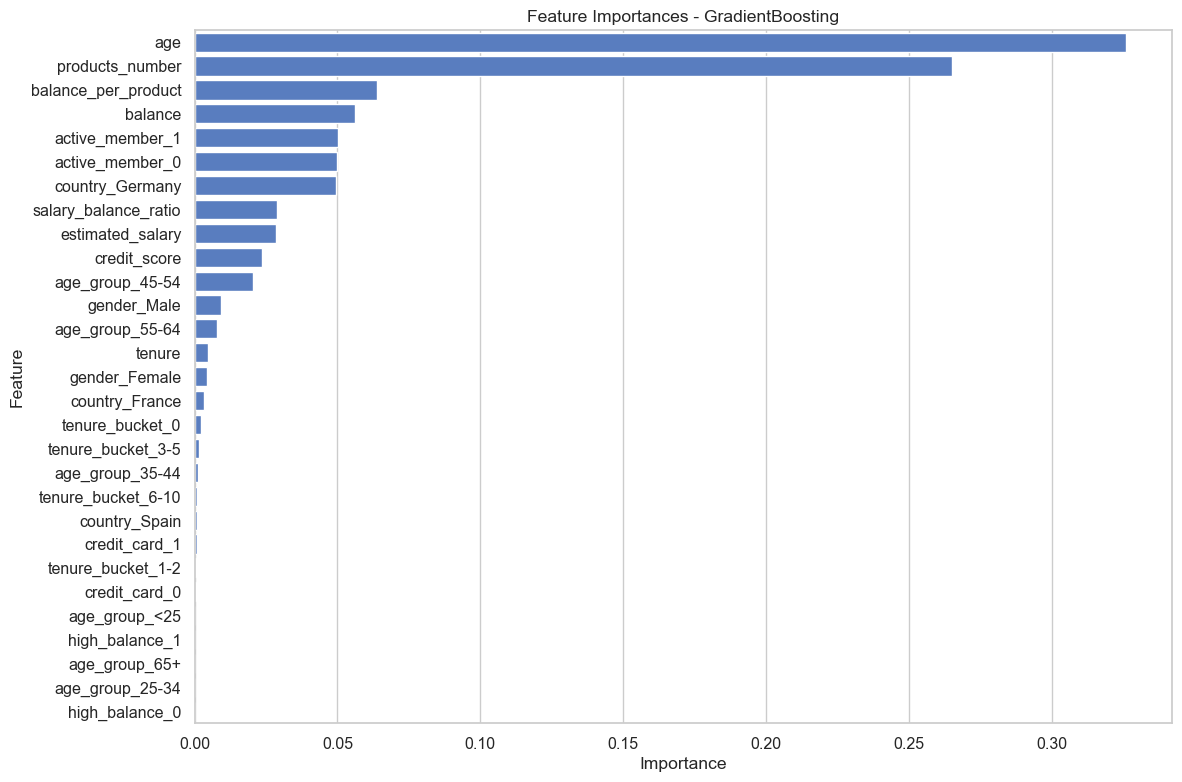

In [23]:
if hasattr(best_model, 'feature_importances_'):
    feature_names = numeric_features + list(best_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features))
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
    plt.title(f'Feature Importances - {best_name}')
    plt.tight_layout()
    plt.show()

# Step 11. Save the best pipeline and preprocessing artifacts

In [24]:
joblib.dump(best_pipeline, 'best_model_pipeline.pkl')
print(f"Best model pipeline saved as 'best_model_pipeline.pkl'")

Best model pipeline saved as 'best_model_pipeline.pkl'


# Step 12. Example : Predict churn for a new customer

In [29]:
# --- New Costumer sample ---
sample = {
    'customer_id': 'CUST12345',
    'credit_score': 700,
    'country': 'France',
    'gender': 'Male',
    'age': 30,
    'tenure': 3,
    'balance': 50000,
    'products_number': 2,
    'credit_card': 1,
    'active_member': 1,
    'estimated_salary': 60000,
}

sample_df = pd.DataFrame([sample])

# --- Apply same feature engineering ---
sample_df['balance_per_product'] = sample_df['balance'] / (sample_df['products_number'].replace(0, np.nan))
sample_df['balance_per_product'].fillna(0, inplace=True)
sample_df['salary_balance_ratio'] = sample_df['estimated_salary'] / (sample_df['balance'].replace(0, np.nan))
sample_df['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
sample_df['salary_balance_ratio'].fillna(sample_df['salary_balance_ratio'].mean(), inplace=True)

bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
sample_df['age_group'] = pd.cut(sample_df['age'], bins=bins, labels=labels)
sample_df['tenure_bucket'] = pd.cut(sample_df['tenure'], bins=[0, 1, 2, 5, 10, 100], labels=['0', '1-2', '3-5', '6-10', '10+'])
sample_df['high_balance'] = (sample_df['balance'] > sample_df['balance'].quantile(0.75)).astype(int)


# Drop ID
sample_df = sample_df.drop(columns=['customer_id'])

# --- Predict
pred = best_pipeline.predict(sample_df)[0]
prob = best_pipeline.predict_proba(sample_df)[0][1]

print(f"Predicted Churn: {pred} (1 means churn, 0 means no churn)")
print(f"Predicted Churn Probability: {prob:.4f}")

Predicted Churn: 0 (1 means churn, 0 means no churn)
Predicted Churn Probability: 0.0173
